In [1]:
using Plots, LaTeXStrings

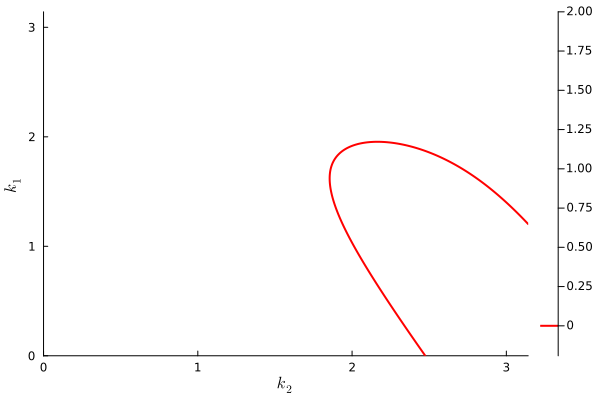

In [ ]:
# Definición de funciones
omega_plus(k, ϵ) = begin
    A = sqrt(ϵ^2 + (1 - ϵ^2) * cos(k/2)^2)
    sqrt(2 + 2A)
end

omega_minus(k, ϵ) = begin
    A = sqrt(ϵ^2 + (1 - ϵ^2) * cos(k/2)^2)
    sqrt(2 - 2A)
end

# Delta for the resonance condition
Delta(k1, k2, ϵ) = begin
    k3 = -k1 - k2
    omega_plus(k1, ϵ) - omega_minus(k2, ϵ) - omega_minus(k3, ϵ)
end

# Parámetros
N = 256
ϵ = 0.4

In [ ]:
function plot_D!(p, N, ϵ; label=nothing, col=:red, show_colorbar=false, ls=:solid, xmax=π,
                 guidefs=16, tickfs=12, legendfs=12)
    k1_vals = range(0, xmax, length=N)
    k2_vals = range(0, xmax, length=N)
    D = compute_D(k1_vals, k2_vals, ϵ)

    ticks = ([0, π/2, π], [L"0", L"\pi/2", L"\pi"])

    contour!(p, k1_vals, k2_vals, D;
             levels=[0],
             color=col,
             linewidth=2,
             linestyle=ls,
             xlabel=L"k_{2}",
             ylabel=L"k_{1}",
             xticks=ticks,
             yticks=ticks,
             xlim=(0, xmax),
             ylim=(0, xmax),
             grid=false,
             label=label,
             colorbar=show_colorbar,
             guidefont=font(guidefs),
             tickfont=font(tickfs),
             legendfont=font(legendfs))

    return p
end


plot_D! (generic function with 1 method)

In [76]:
function plot_D(N, ϵ)
    p = plot()
    plot_D!(p, N, ϵ)
    return p
end

plot_D (generic function with 1 method)

In [ ]:
function plot_multiple_D(N, ϵ_values; colors=[:red, :blue, :green, :orange, :purple],
                         linestyles=[:solid, :dash, :dashdot, :dot, :dashdotdot],
                         xmax=π, guidefs=16, tickfs=12, legendfs=12)
    p = plot(legend=:topright, guidefont=font(guidefs), tickfont=font(tickfs), legendfont=font(legendfs))
    for (i, ϵ) in enumerate(ϵ_values)
        col = colors[mod1(i, length(colors))]
        ls  = linestyles[mod1(i, length(linestyles))]

        plot_D!(p, N, ϵ; label=nothing, col=col, show_colorbar=(i==1), ls=ls,
                xmax=xmax, guidefs=guidefs, tickfs=tickfs, legendfs=legendfs)

        plot!(p, [], [], color=col, linewidth=2, linestyle=ls, label="ϵ = $ϵ")
    end
    return p
end

plot_multiple_D (generic function with 1 method)

In [80]:
plot_multiple_D(N, [0.2, 0.4, 0.45])

LoadError: KeyError: key :labelfont not found

In [3]:
using LinearAlgebra
using Plots
using LaTeXStrings
gr()

# ====================================================================
# PARÁMETROS DEL SISTEMA MONOATÓMICO REAL
# ====================================================================
const a_diat = 1.0                  # Constante de red diatómica original
const a_mono = a_diat / 2           # Distancia REAL entre átomos en la cadena homogénea
const m = 1.0                       # Masa atómica
const κ = 1.0                       # Constante de resorte única (Δκ = 0)

# El rango de k ahora se extiende hasta el borde monoatómico verdadero: 2π/a
# (El doble de grande que el caso diatómico)
k_max_mono = 2 * π / a_diat         # Es decir, π / a_mono
k_range = range(0.0, stop=k_max_mono, length=1200)

# ====================================================================
# 1. RELACIÓN DE DISPERSIÓN MONOATÓMICA
# ====================================================================
# Una única rama acústica real y continua
function omega_mono(k)
    return 2 * sqrt(κ / m) * abs(sin(k * a_mono / 2))
end

# ====================================================================
# 2. BÚSQUEDA DE RESONANCIAS DE 3 ONDAS (Cinética de Ondas Directa)
# ====================================================================
# Queremos evaluar la condición: ω(k₁) + ω(k₂) = ω(k₃)
# Con la conservación del momento real: k₃ = k₁ + k₂ - G * (2π / a_mono)
# Nota que para procesos Normales G=0, y para Umklapp monoatómicos G=±1, ±2...
# El vector de red recíproco real es b = 2π / a_mono = 4π / a_diat

function verificar_resonancias_mono(k_range)
    N = length(k_range)
    # Matriz para guardar dónde se cumple la conservación de energía
    # Resonancia = 1, No resonancia = 0
    mapa_resonancia = zeros(N, N)

    # Umbral de tolerancia numérica para la igualdad de frecuencias
    tol = 1e-8

    for i in 1:N
        for j in 1:N
            k1 = k_range[i]
            k2 = k_range[j]

            # Suma de momentos (onda resultante directa)
            k3_directo = k1 + k2

            # CORRECCIÓN: Ajustar por periodicidad real de la red (Umklapp Monoatómico Real)
            # Llevamos k3 al rango [0, k_max_mono) usando módulo aritmética
            k3 = mod(k3_directo, k_max_mono)

            # Evaluamos la conservación de energía
            ω1 = omega_mono(k1)
            ω2 = omega_mono(k2)
            ω3 = omega_mono(k3)

            # Condición de conservación de energía
            if abs(ω1 + ω2 - ω3) < tol
                mapa_resonancia[i, j] = 1.0  # ¡Resonancia encontrada!
            end
        end
    end
    return mapa_resonancia
end

# Execución del cálculo
println("Calculando el mapa de resonancias monoatómico real...")
mapa = verificar_resonancias_mono(k_range)

# ====================================================================
# 3. GRAFICACIÓN DEL RESULTADO
# ====================================================================
# Graficamos el resultado en el espacio (k₁, k₂) extendido real
ticks_pos = [0, π/a_diat, 2*π/a_diat]
ticks_labels = [L"0", L"\frac{\pi}{a}", L"\frac{2\pi}{a}"]

p = heatmap(k_range, k_range, mapa,
            color=:binary,  # Blanco (0) y Negro (1)
            xlabel=L"k_1", ylabel=L"k_2",
            title="FPUT-α con Tratamiento Monoatómico Real (Δκ = 0)",
            xticks=(ticks_pos, ticks_labels),
            yticks=(ticks_pos, ticks_labels),
            xlims=(0, k_max_mono), ylims=(0, k_max_mono),
            colorbar=false, size=(700, 600))

# Guardar la figura
savefig(p, "resonancias_monoatomicas_reales.png")
println("¡Gráfica guardada como 'resonancias_monoatomicas_reales.png'!")


Calculando el mapa de resonancias monoatómico real...
¡Gráfica guardada como 'resonancias_monoatomicas_reales.png'!
